In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin vers le dataset
data_path = os.path.join('..', 'data', 'city_lifestyle_dataset.csv')

# Chargement
try:
    df = pd.read_csv(data_path)
    print("Donnees chargees avec succes.")
except FileNotFoundError:
    print("Erreur : fichier introuvable.")

# Apercu rapide
print(f"Dimensions : {df.shape}")
print(df.head())

Donnees chargees avec succes.
Dimensions : (300, 10)
       city_name country  population_density  avg_income  \
0      Old Vista  Europe                2775        3850   
1      Beachport  Europe                3861        3700   
2  Valleyborough  Europe                2562        4310   
3           City  Europe                3192        3970   
4          Falls  Europe                3496        4320   

   internet_penetration  avg_rent  air_quality_index  public_transport_score  \
0                  86.4      1310                 43                    52.0   
1                  78.1      1330                 42                    62.8   
2                  80.1      1330                 39                    73.2   
3                  81.2      1480                 60                    49.2   
4                 100.0      1510                 64                    93.7   

   happiness_score  green_space_ratio  
0              8.5               23.8  
1              8.1       

In [ ]:
# Exclusion des colonnes textuelles et index
cols_to_exclude = ['Unnamed: 0', 'City', 'Country', 'Region']
df_temp = df.drop(columns=[c for c in cols_to_exclude if c in df.columns])

# Selection stricte du numerique avant calcul de la mediane
df_numeric = df_temp.select_dtypes(include=['number'])
df_numeric = df_numeric.fillna(df_numeric.median())

print("Colonnes retenues pour UMAP :")
print(df_numeric.columns.tolist())

Colonnes retenues pour UMAP :
['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']


c:\Users\sebag\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Resultat exporte dans : ..\outputs\umap_emb_2d.csv


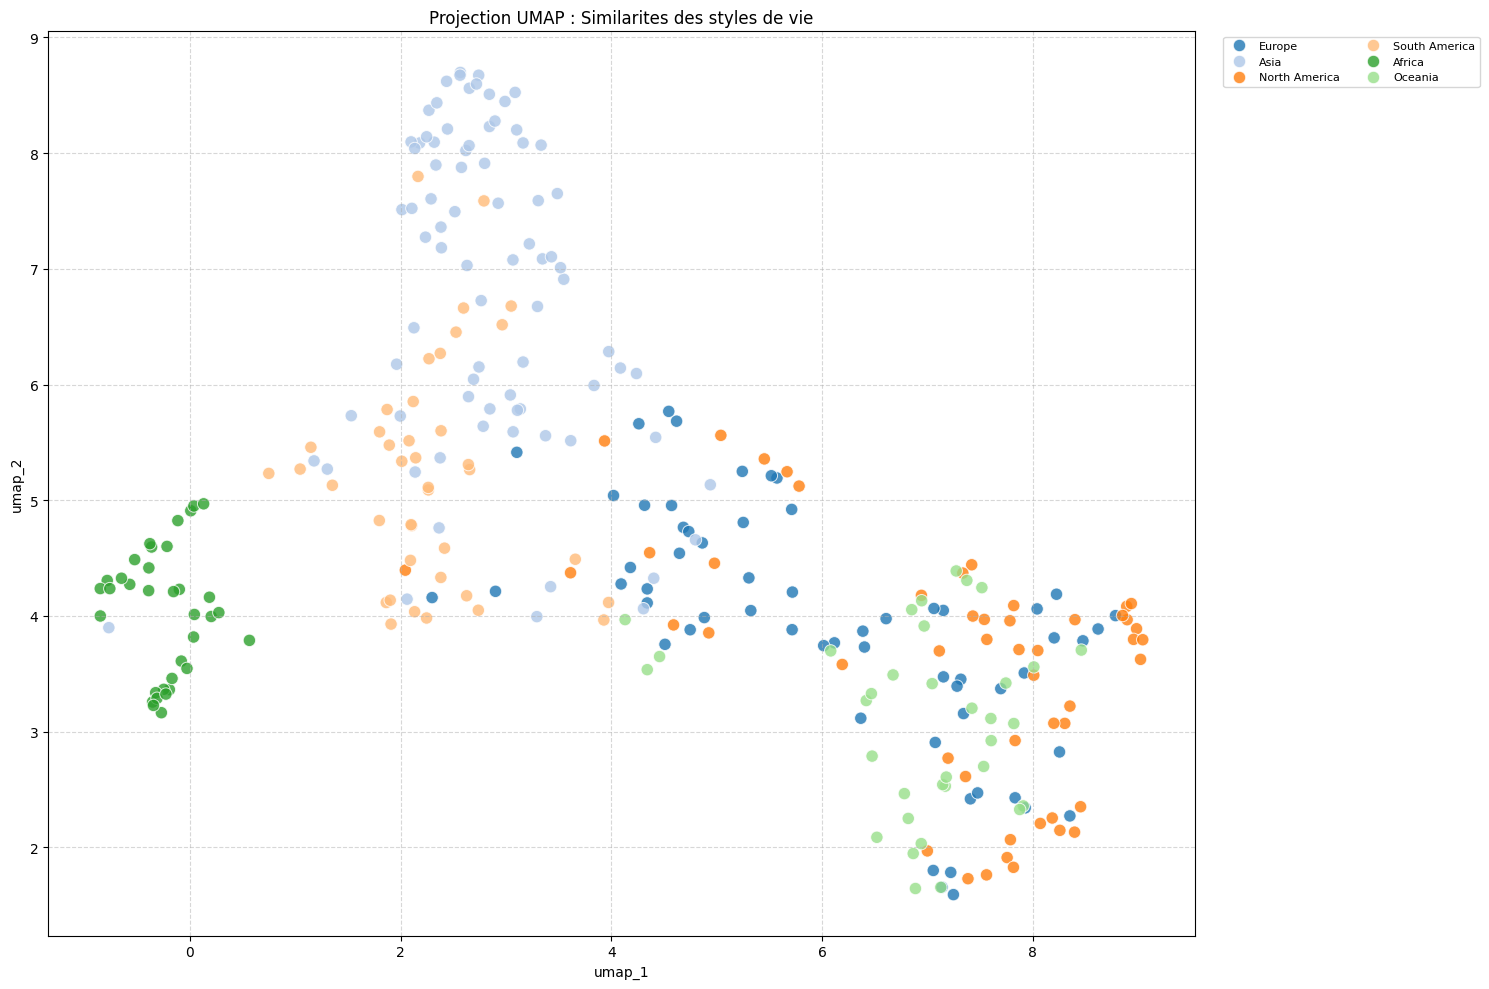

In [31]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardisation
scaled_data = StandardScaler().fit_transform(df_numeric)

# Algorithme UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(scaled_data)

# Creation du DataFrame de sortie
df_umap = pd.DataFrame(embedding, columns=['umap_1', 'umap_2'])

# Detection automatique de la colonne Pays/Country
col_country = [c for c in df.columns if 'count' in c.lower()]
if col_country:
    country_label = col_country[0]
    df_umap['Country'] = df[country_label].values
    hue_param = 'Country'
else:
    hue_param = None
    print("Attention : Colonne 'Country' non detectee pour la coloration.")

# Exportation dans /outputs
output_path = os.path.join('..', 'outputs', 'umap_emb_2d.csv')
df_umap.to_csv(output_path, index=False)
print(f"Resultat exporte dans : {output_path}")

# Visualisation
plt.figure(figsize=(15, 10))
sns.scatterplot(
    x='umap_1', 
    y='umap_2', 
    hue=hue_param, 
    data=df_umap, 
    s=80, 
    palette='tab20' if hue_param else None,
    alpha=0.8
)

# Legende
if hue_param:
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fontsize='8')

plt.title('Projection UMAP : Similarites des styles de vie')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

La projection UMAP révèle une structuration des villes selon leurs styles de vie. Les villes africaines forment un groupe distinct, indiquant un profil homogène et différencié. Les villes asiatiques montrent une dispersion importante, traduisant une diversité interne élevée. En revanche, les villes européennes, nord-américaines, sud-américaines et océaniques sont regroupées vers la droite du graphique, avec un chevauchement notable entre ces continents. On remarque la capacité de cette méthode à capturer des relations complexes et non linéaires tout en conservant la proximité des profils similaires.